# Initial imports and constants 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib
import pandas as pd 
import pickle
import batman
import dill

In [2]:
TESS_offset = 2457000


# Load transit times 

In [42]:
file = 'toi_1339_bls_data.pkl'
with open(file, 'rb') as f:
    data = pickle.load(f)

time = data['time']
flux = data['flux']
flux_err = data['flux_err']

In [43]:
### Read results
d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354909  0.001073
1             1      2  1733.115586  0.001797
2             1      3  1741.996174  0.001416
3             1      5  1759.758648  0.001363
4             1      6  1768.637415  0.003105
..          ...    ...          ...       ...
106           3     42  3354.303788  0.002451
107           3     43  3392.661021  0.001888
108           3     47  3546.072794  0.001416
109           3     49  3622.770169  0.001992
110           3     50  3661.127060  0.002638

[111 rows x 4 columns]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_9846/2177619484.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [44]:
tc_2 = np.array(d.Tc[d.Planet_num==2])
tc_3 = np.array(d.Tc[d.Planet_num==3])
print(tc_b)

[1726.05497471 1754.63404397 1783.21147862 1811.79970925 1840.37499164
 1897.53491287 1926.11611318 2440.54520822 2640.60685756 2697.77150694
 2726.35289967 2812.09680375 2840.6727498  2926.41876251 3297.97070174
 3355.12979823 3383.71060541 3440.87695377 3555.19563725 3583.77180949
 3612.34968722 3640.93118816]


In [69]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

rho_star = 1.37 # [g/cm^3]

0.44108956006688715
0.11027239001672175


In [46]:
per_2=  28.5805 #28.579743
rp_2= 0.0306 #0.03118
b_2=  0.63 #0.630


In [47]:
per_3=  38.3525 #38.353037
rp_3=  0.0302 #0.02916
b_3=  0.48 #0.440


In [48]:
dur_2_guess = 4.5 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 
dur_3_guess = 5.5 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


# Fit for transit duration

In [52]:
def bootstrap_transit_dur(time, flux, flux_err, dur_range, dur_guess, tcs, per, rp, b, u1, u2, num_bootstrap=100):
    '''
    tc: list of arrays, each array contains a grid of tc values around the guess for each transit
    tc_guess: array of tc guess values, one per transit
    '''
    dur_chi = np.zeros(len(tcs))
    errors = []

    for j in range(len(tcs)):
        dur_grid = dur_range  # fine grid of tc values around guess for this transit
        dur_samples = []
        tc = tcs[j]

        for _ in range(num_bootstrap):
            # Bootstrap resample the data within the relevant time window
            start = tc - dur_guess*1.5
            end = tc + dur_guess*1.5
            mask = (time > start) & (time < end)

            time_boot = time[mask]
            flux_boot = flux[mask]
            flux_err_boot = flux_err[mask]

            # Resample with replacement
            resample_idx = np.random.choice(len(time_boot), size=len(time_boot), replace=True)
            time_sample = time_boot[resample_idx]
            flux_sample = flux_boot[resample_idx]
            flux_err_sample = flux_err_boot[resample_idx]

            chi_sq = np.zeros(len(dur_grid))

            for i, dur in enumerate(dur_grid):
                params = batman.TransitParams()
                params.t0 = tc
                params.per = per
                params.rp = rp
                params.b = b
                params.T14 = dur
                params.u = [u1, u2]
                params.limb_dark = "quadratic"

                try:
                    model = batman.TransitModel(params, time_sample)
                    model_flux = model.light_curve(params)
                    chi_sq[i] = np.sum(((flux_sample - model_flux) / flux_err_sample)**2)
                except RuntimeError:
                    chi_sq[i] = np.inf  # If model fails, mark as bad

            best_dur = dur_grid[np.argmin(chi_sq)]
            dur_samples.append(best_dur)

        dur_samples = np.array(dur_samples)
        median_dur = np.median(dur_samples)
        dur_chi[j] = median_dur
        err_lo = np.percentile(dur_samples, 16) - median_dur
        err_hi = np.percentile(dur_samples, 84) - median_dur
        errors.append((abs(err_lo), abs(err_hi)))

    return dur_chi, errors


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, durations, per, rp, b, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
        buffer = durations[i] * 1.5
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        T14 = durations[i]
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


## planet 2

In [59]:
dur_2_range = np.linspace(dur_2_guess-0.044, dur_2_guess+0.044, 1000)
# print(dur_range_2)

In [60]:
dur_chi_2, dur_err_2 = bootstrap_transit_dur(time, flux, flux_err, dur_2_range, dur_2_guess, tc_2, per_2, rp_2, b_2, u1, u2)

In [61]:
print(dur_2_guess)
print(dur_chi_2)

0.18750015
[0.18754419 0.19053919 0.18644309 0.18547412 0.18890956 0.18816081
 0.19036301 0.18877743 0.18380045 0.1897464  0.1926533  0.19133198
 0.18983448 0.19058323 0.18912978 0.18653118 0.19128794 0.18776441
 0.19097963 0.18261126 0.18657523 0.19062728]


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_9846/909353358.py:41: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
/opt/homebrew/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


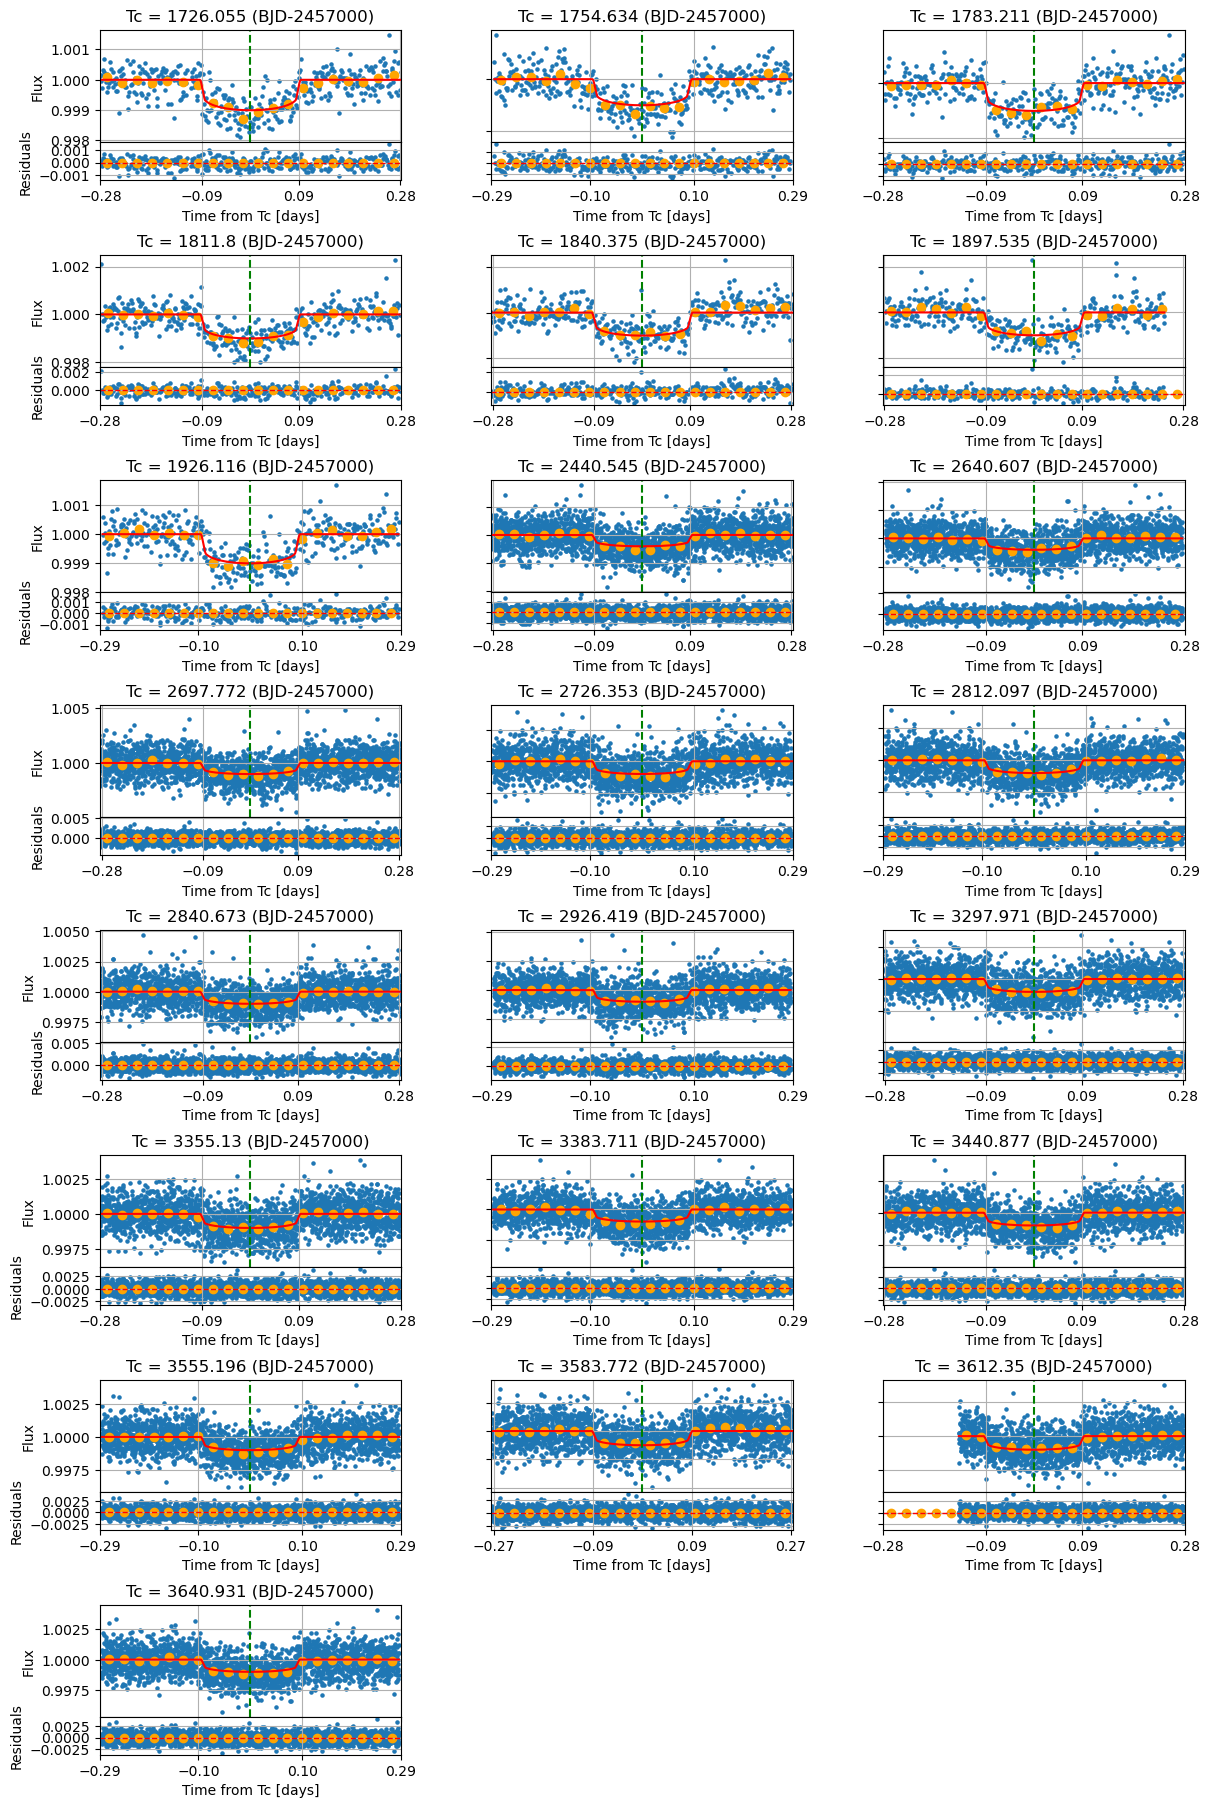

In [64]:
plot_transits(tc_2, dur_chi_2, per_2, rp_2, b_2, u1, u2)

## Planet 3

In [65]:
dur_3_range = np.linspace(dur_3_guess-0.044, dur_3_guess+0.044, 1000)

In [66]:
dur_chi_3, dur_err_3 = bootstrap_transit_dur(time, flux, flux_err, dur_3_range, dur_3_guess, tc_3, per_3, rp_3, b_3, u1, u2)

In [67]:
print(dur_3_guess)
print(dur_chi_3)

0.22916685
[0.23260229 0.23009177 0.23339508 0.23220589 0.23277846 0.23255824
 0.23017986 0.2295192  0.22542311 0.23009177 0.23370339 0.22956325
 0.22947516 0.23132501 0.22824193 0.22824193 0.23048817]


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_9846/909353358.py:41: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


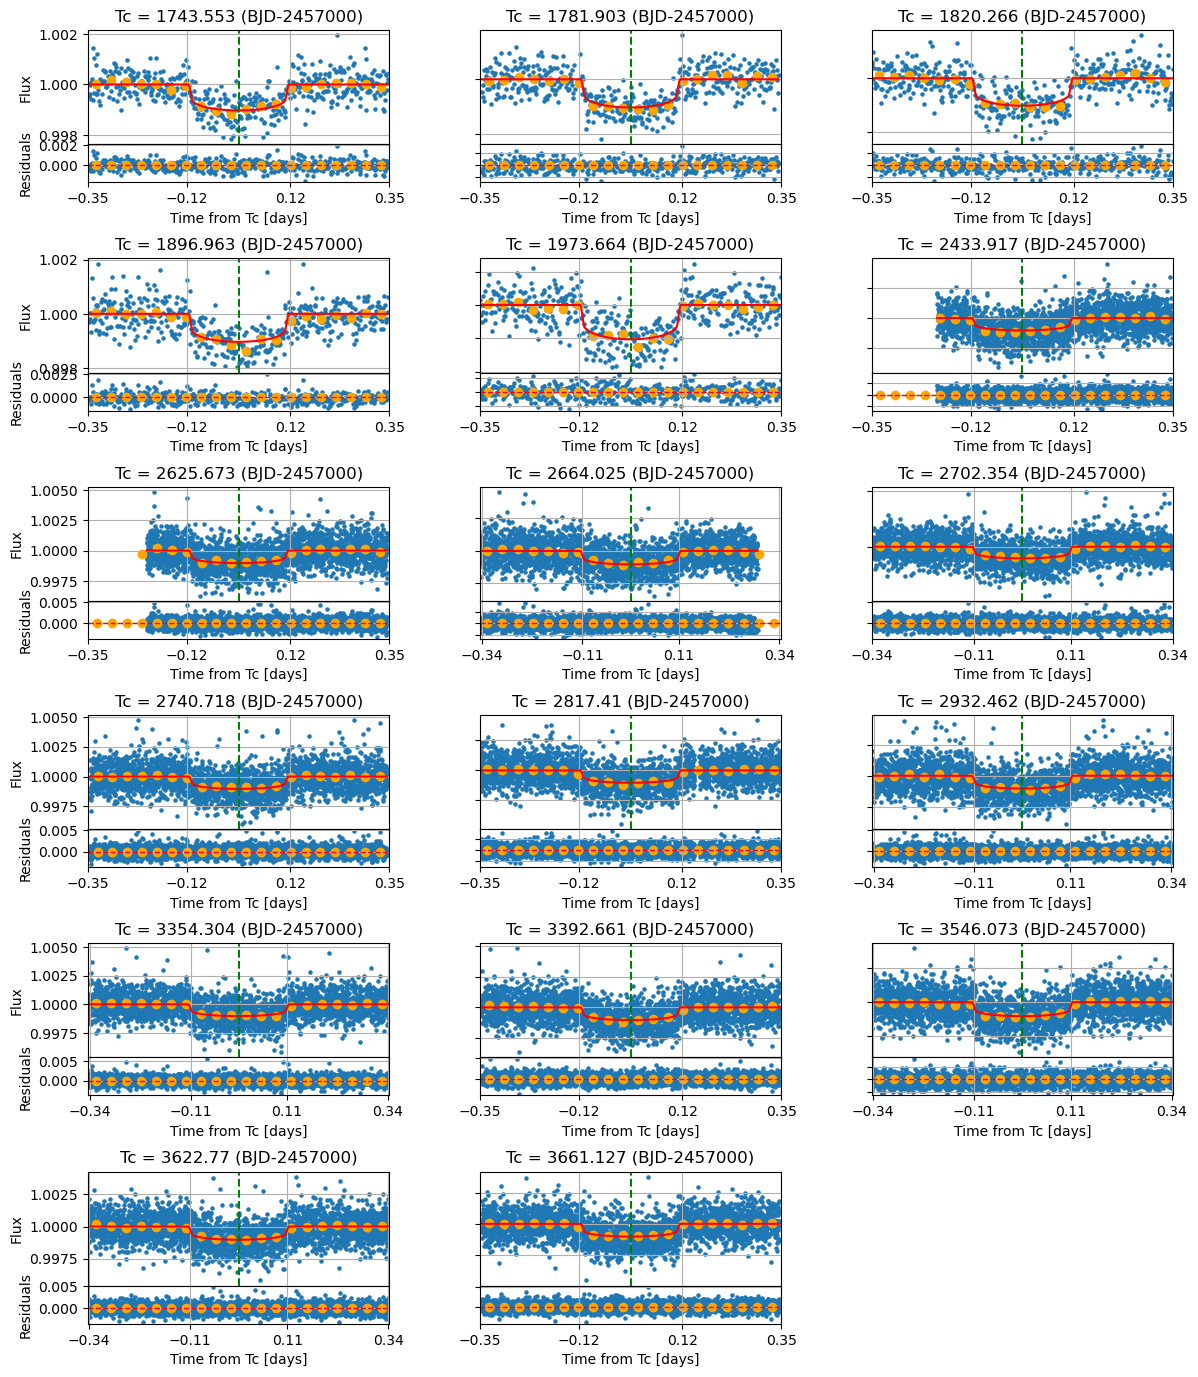

In [68]:
plot_transits(tc_3, dur_chi_3, per_3, rp_3, b_3, u1, u2)

# Calculate nominal duration

In [20]:
from astropy.constants import G
from astropy import units as u
G_new_units = G.to(u.cm**3 / (u.g * u.day**2))

G_const = G_new_units.value

In [21]:
def T_nominal(P, rp_rstar, rho_star):
    from astropy.constants import G
    from astropy import units as u
    G_new_units = G.to(u.cm**3 / (u.g * u.day**2))
    G_const = G_new_units.value
    term1 = P / np.pi
    term2_num = (1 + rp_rstar)**2
    term2_den = ((G_const*(P**2)*rho_star)/(3*np.pi))**(2./3.)
    term2 = np.arcsin(np.sqrt(term2_num / term2_den))
    T = term1 * term2
    return T


# Find constraints 

In [3]:
# predicted duration ratio 
file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'

# file_name = '1339_jnkep_fit_1339-1000burn-2000step.pkl'
# file_name = '1339_jnkep_fit_1339-100burn-200step.pkl'
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [4]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.23      0.41     23.37      1.17
 ecosw_scaled[1]      0.35      0.06      0.35      0.27      0.43     23.05      1.17
 esinw_scaled[0]      0.36      0.09      0.35      0.24      0.51     57.54      1.08
 esinw_scaled[1]      0.38      0.08      0.37      0.28      0.51     56.57      1.08
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    262.42      1.04
period_scaled[1]      0.50      0.00      0.50      0.50      0.50   1759.29      1.00
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    535.57      1.02
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01   1292.87      1.01
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    117.37      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.52   2171.55      1.00

Number of divergences: 749


In [5]:
posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})

{'ecc': (4, 2000, 2), 'ecosw': (4, 2000, 2), 'ecosw_scaled': (4, 2000, 2), 'ediff': (4, 2000), 'esinw': (4, 2000, 2), 'esinw_scaled': (4, 2000, 2), 'period': (4, 2000, 2), 'period_scaled': (4, 2000, 2), 'pmass': (4, 2000, 2), 'pmass_scaled': (4, 2000, 2), 'tcmodel': (4, 2000, 39), 'tic': (4, 2000, 2), 'tic_scaled': (4, 2000, 2)}


In [6]:
good_chain_idxs = [0,1,2]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples_flat = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}


In [7]:
### posterior samples 
ecosw_2_jnkep = samples_flat["ecosw"][:, 0]
esinw_2_jnkep = samples_flat["esinw"][:, 0]
Per_2 = samples_flat["period"][:,0] # [days]
Tc_2 = samples_flat["tic"][:,0] # [days]
pmass_2 = samples_flat["pmass"][:, 0] # [solar mass]

ecosw_3_jnkep = samples_flat["ecosw"][:, 1]
esinw_3_jnkep = samples_flat["esinw"][:, 1]
Per_3 = samples_flat["period"][:,1] # [days]
Tc_3 = samples_flat["tic"][:,1] # [days]
pmass_3 = samples_flat["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_2 = pmass_2 * convert
pmass_earth_3 = pmass_3 * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_2 = np.sqrt(ecosw_2_jnkep**2 + esinw_2_jnkep**2)
omega_rad_2 = np.arctan2(esinw_2_jnkep, ecosw_2_jnkep)
omega_deg_2 = np.rad2deg(omega_rad_2)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_3 = np.sqrt(ecosw_3_jnkep**2 + esinw_3_jnkep**2)
omega_rad_3 = np.arctan2(esinw_3_jnkep, ecosw_3_jnkep)
omega_deg_3 = np.rad2deg(omega_rad_3)


In [10]:
# samples: P, rp, b, e, w

In [11]:
# compute physical stellar density for each sample from {P, rp, b, e, w} samples 
def rho_sample(P, rp, b, T14, e, w):
    from astropy.constants import G
    from astropy import units as u
    G_new_units = G.to(u.cm**3 / (u.g * u.day**2))
    G_const = G_new_units.value

    term1 = (3*np.pi) / (G_const*P**2)
    term2_num = (1 + rp)**2 - b**2
    sine_num = T14 * np.pi * (1 + e*np.sin(w))
    sine_den = P*np.sqrt(1-e**2)
    sine_term = sine_num / sine_den
    term2_den = (np.sin(sine_term))**2
    term2_frac = term2_num / term2_den
    term2 = (term2_frac + b**2)**(3./2.)
    rho = term1 * term2
    return rho 
    


# log-likelyhood of each set of physical stellar density and random draw of stellar density from Gaia
def log_like(rho_samp, rho_gaia, rho_gaia_err):
    term_num = rho_samp - rho_gaia
    term_den = rho_gaia_err
    term = term_num / term_den
    log_lk = -(1./2.)*(term)**2
    return log_lk

def weights_(log_like):
    w = np.exp(log_like)
    w /= np.sum(w)
    return w

# approximate duration ratio

In [12]:
rng = np.random.default_rng(42)
N = len(Per_2)

In [13]:
### use stellar density from Lubin
rho_star = 1.37 #[g/cm^3]
rho_star_err = 0.11

In [14]:
### create posteriors from Lubin 2022
### planet 2
T14_2 = 4.5 * 0.0416667
T14_2_err = 0.2 * 0.0416667
T14_2_samples = rng.normal(T14_2, T14_2_err, N)
T14_2_samples = np.clip(T14_2_samples, 1e-9, None)  # days

b_2 = 0.63
b_2_err = 0.02
b_2_samples = rng.normal(b_2, b_2_err, N)
b_2_samples = np.clip(b_2_samples, 0.0, 0.999999)

rp_2 = 0.0306
rp_2_err = 0.0007
rp_2_samples = rng.normal(rp_2, rp_2_err, N)
rp_2_samples = np.clip(rp_2_samples, 1e-9, None)

e_2_samples = rng.uniform(0.0, 1.0, N)
omega_2_samples = rng.uniform(0.0, 2*np.pi, N)


### planet 3
T14_3 = 5.5 * 0.0416667
T14_3_err = 0.3 * 0.0416667
T14_3_samples = rng.normal(T14_3, T14_3_err, N)
T14_3_samples = np.clip(T14_3_samples, 1e-9, None)  # days

b_3 = 0.48
b_3_err = 0.04
b_3_samples = rng.normal(b_3, b_3_err, N)
b_3_samples = np.clip(b_3_samples, 0.0, 0.999999)

rp_3 = 0.0302
rp_3_err = 0.0007
rp_3_samples = rng.normal(rp_3, rp_3_err, N)
rp_3_samples = np.clip(rp_3_samples, 1e-9, None)

e_3_samples = rng.uniform(0.0, 1.0, N)
omega_3_samples = rng.uniform(0.0, 2*np.pi, N)



In [15]:
def stratified_resample(N, weights, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    positions = (rng.random(N) + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    return np.searchsorted(cumsum, positions)

## Planet 2

In [16]:
rho_samp_2 = rho_sample(Per_2, rp_2_samples, b_2_samples, T14_2_samples, e_2_samples, omega_2_samples)
log_likelihood_2 = log_like(rho_samp_2, rho_star, rho_star_err)
weights_2 = weights_(log_likelihood_2)

In [17]:
idx_2 = stratified_resample(N, weights_2, rng)
post_Per_2 = Per_2[idx_2]
post_T14_2 = T14_2_samples[idx_2]
post_rp_2 = rp_2_samples[idx_2]
post_b_2 = b_2_samples[idx_2]
post_e_2 = e_2_samples[idx_2]
post_omega_2 = omega_2_samples[idx_2] % (2*np.pi)
post_rho_2 = rho_samp_2[idx_2]

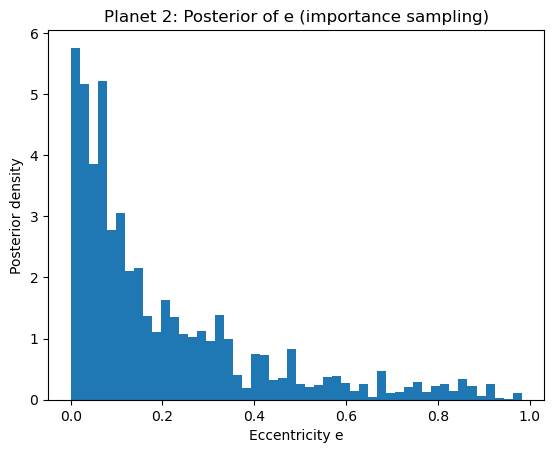

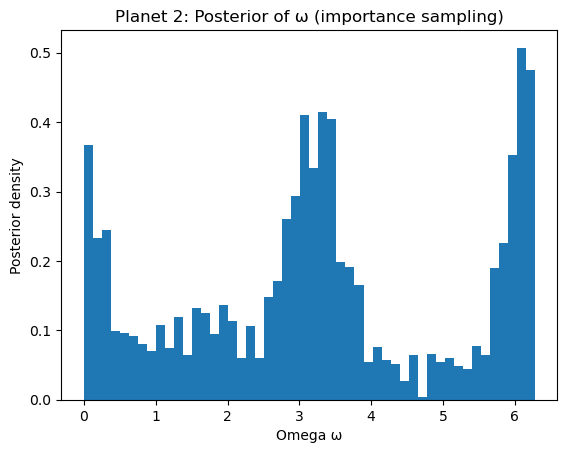

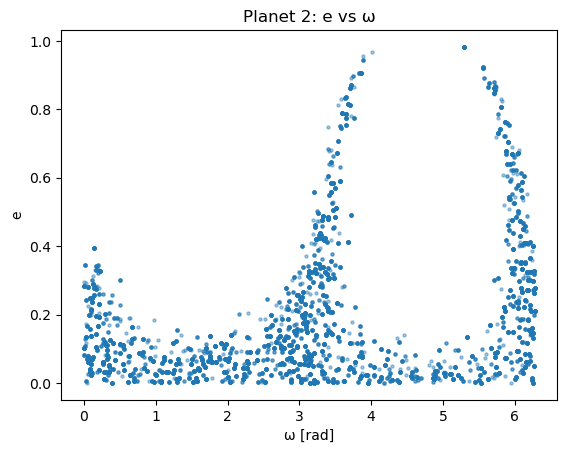

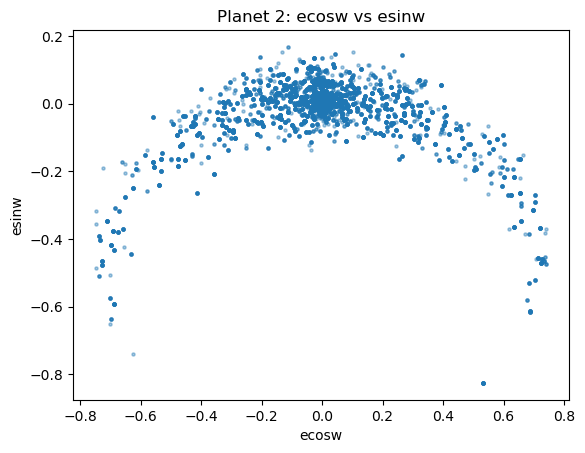

In [36]:
# Quick plots
plt.hist(post_e_2, bins=50, density=True)
plt.xlabel("Eccentricity e")
plt.ylabel("Posterior density")
plt.title("Planet 2: Posterior of e (importance sampling)")
plt.show()

plt.hist(post_omega_2, bins=50, density=True)
plt.xlabel("Omega ω")
plt.ylabel("Posterior density")
plt.title("Planet 2: Posterior of ω (importance sampling)")
plt.show()

plt.scatter(post_omega_2, post_e_2, s=5, alpha=0.4)
plt.xlabel("ω [rad]")
plt.ylabel("e")
plt.title('Planet 2: e vs ω')
plt.show()

esinw_2 = post_e_2 * np.sin(post_omega_2)
ecosw_2 = post_e_2 * np.cos(post_omega_2)
plt.scatter(ecosw_2, esinw_2, s=5, alpha=0.4)
plt.xlabel('ecosw')
plt.ylabel('esinw')
plt.title('Planet 2: ecosw vs esinw')
plt.show()

In [23]:
T_nom_2 = T_nominal(post_Per_2, post_rp_2, post_rho_2)
# T_nom_2 = T_nominal(Per_2, rp_2_samples, rho_samp_2)

In [24]:
T14_Tnom_2 = post_T14_2 / T_nom_2
print(post_T14_2 / T_nom_2)

[0.72118807 0.8133386  0.8133386  ... 0.7793784  0.7793784  0.7793784 ]


Median: 0.7806529
16th percentile: 0.7454628944396973
84th percentile: 0.8128378391265869


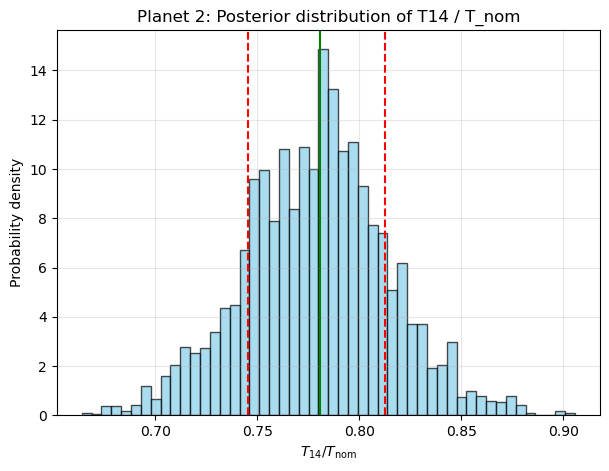

In [25]:
# Quick statistics
print("Median:", np.median(T14_Tnom_2))
print("16th percentile:", np.percentile(T14_Tnom_2, 16))
print("84th percentile:", np.percentile(T14_Tnom_2, 84))
p16_2, p84_2 = np.percentile(T14_Tnom_2, [16, 84])
median_2 = np.median(T14_Tnom_2)

# Plot histogram
plt.figure(figsize=(7,5))
plt.hist(T14_Tnom_2, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
# Add vertical dashed lines
plt.axvline(p16_2, color='red', linestyle='--', label='16th percentile')
plt.axvline(p84_2, color='red', linestyle='--', label='84th percentile')
plt.axvline(median_2, color='green', linestyle='-', label='Median')

plt.xlabel(r"$T_{14} / T_\mathrm{nom}$")
plt.ylabel("Probability density")
plt.title("Planet 2: Posterior distribution of T14 / T_nom")
plt.grid(alpha=0.3)
plt.show()

## Planet 3

In [26]:
rho_samp_3 = rho_sample(Per_3, rp_3_samples, b_3_samples, T14_3_samples, e_3_samples, omega_3_samples)
log_likelihood_3 = log_like(rho_samp_3, rho_star, rho_star_err)
weights_3 = weights_(log_likelihood_3)

In [37]:
idx_3 = stratified_resample(N, weights_3, rng)
post_Per_3 = Per_3[idx_3]
post_T14_3 = T14_3_samples[idx_3]
post_rp_3 = rp_3_samples[idx_3]
post_b_3 = b_3_samples[idx_3]
post_e_3 = e_3_samples[idx_3]
post_omega_3 = omega_3_samples[idx_3] 
post_rho_3 = rho_samp_3[idx_3]

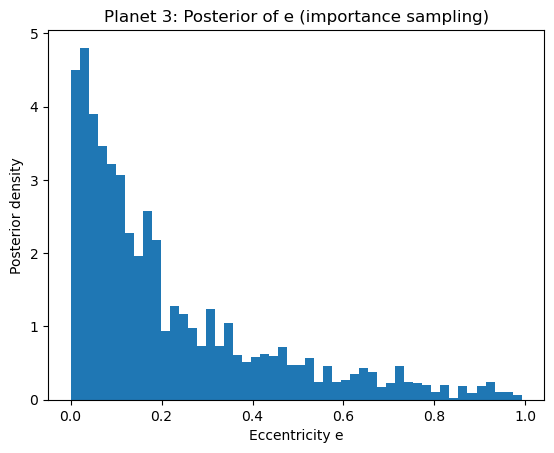

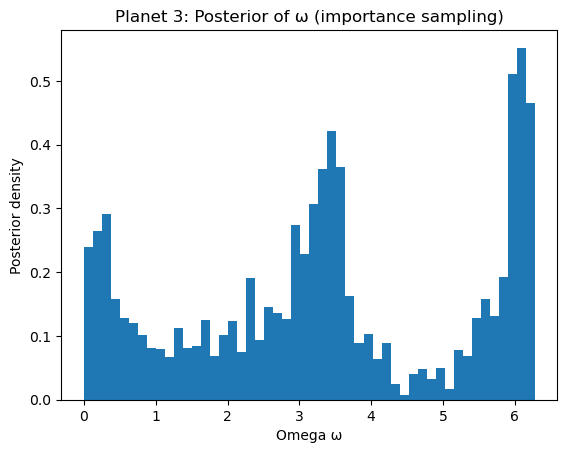

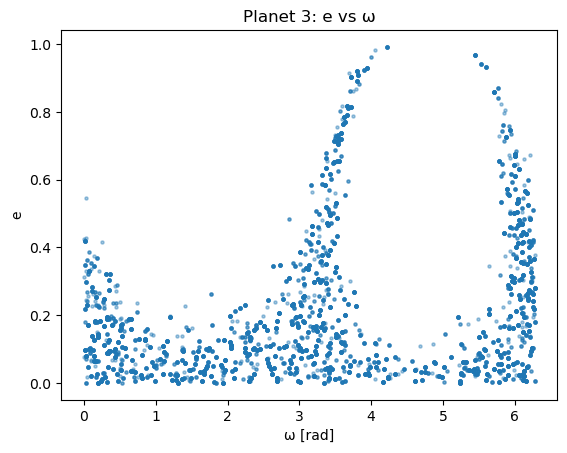

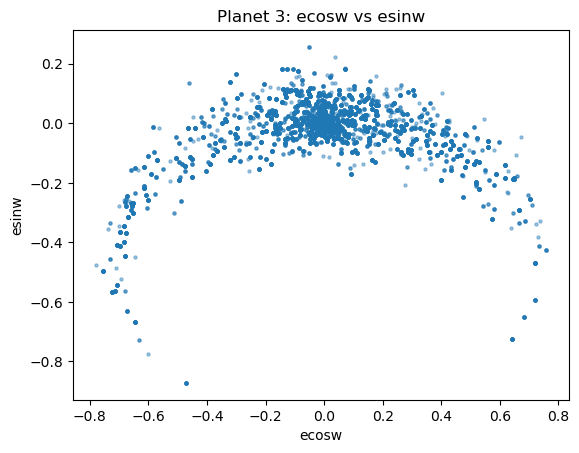

In [38]:
# Quick plots
plt.hist(post_e_3, bins=50, density=True)
plt.xlabel("Eccentricity e")
plt.ylabel("Posterior density")
plt.title("Planet 3: Posterior of e (importance sampling)")
plt.show()

plt.hist(post_omega_3, bins=50, density=True)
plt.xlabel("Omega ω")
plt.ylabel("Posterior density")
plt.title("Planet 3: Posterior of ω (importance sampling)")
plt.show()

# plt.hexbin(post_omega_2 % (2*np.pi), post_e_2, gridsize=60, bins='log')
# plt.xlabel("ω [rad]")
# plt.ylabel("e")
# plt.title("Joint posterior (e, ω)")
# plt.show()

plt.scatter(post_omega_3, post_e_3, s=5, alpha=0.4)
plt.xlabel("ω [rad]")
plt.ylabel("e")
plt.title('Planet 3: e vs ω')
plt.show()

esinw_3 = post_e_3 * np.sin(post_omega_3)
ecosw_3 = post_e_3 * np.cos(post_omega_3)
plt.scatter(ecosw_3, esinw_3, s=5, alpha=0.4)
plt.xlabel('ecosw')
plt.ylabel('esinw')
plt.title('Planet 3: ecosw vs esinw')
plt.show()

In [39]:
T_nom_3 = T_nominal(post_Per_3, post_rp_3, post_rho_3)
# T_nom_2 = T_nominal(Per_2, rp_2_samples, rho_samp_2)

In [40]:
T14_Tnom_3 = post_T14_3 / T_nom_3
print(post_T14_3 / T_nom_3)

[0.7551978  0.7551978  0.82345444 ... 0.862299   0.862299   0.8981218 ]


Median: 0.866844
16th percentile: 0.8165788054466248
84th percentile: 0.9091013073921204


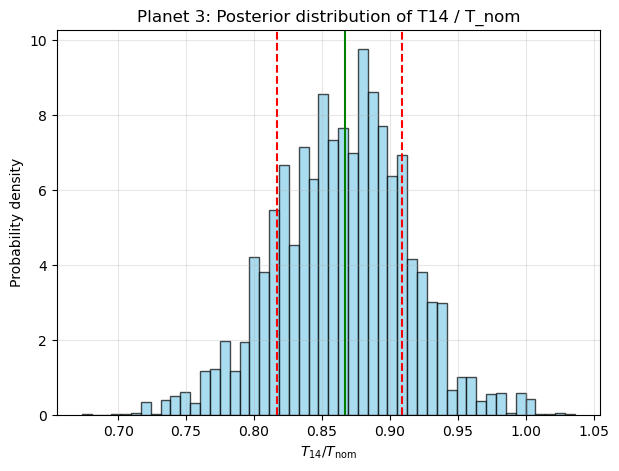

In [41]:
# Quick statistics
print("Median:", np.median(T14_Tnom_3))
print("16th percentile:", np.percentile(T14_Tnom_3, 16))
print("84th percentile:", np.percentile(T14_Tnom_3, 84))
p16_3, p84_3 = np.percentile(T14_Tnom_3, [16, 84])
median_3 = np.median(T14_Tnom_3)

# Plot histogram
plt.figure(figsize=(7,5))
plt.hist(T14_Tnom_3, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
# Add vertical dashed lines
plt.axvline(p16_3, color='red', linestyle='--', label='16th percentile')
plt.axvline(p84_3, color='red', linestyle='--', label='84th percentile')
plt.axvline(median_3, color='green', linestyle='-', label='Median')

plt.xlabel(r"$T_{14} / T_\mathrm{nom}$")
plt.ylabel("Probability density")
plt.title("Planet 3: Posterior distribution of T14 / T_nom")
# plt.legend()
plt.grid(alpha=0.3)
plt.show()

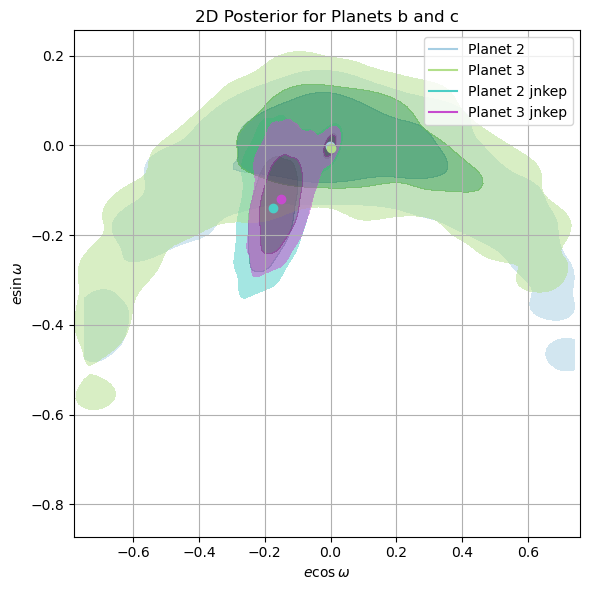

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_2, esinw_2)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_3, esinw_3)

Xb_jnkep, Yb_jnkep, Zb_jnkep, kde_b_jnkep = compute_kde_contour_levels(ecosw_2_jnkep, esinw_2_jnkep)
Xc_jnkep, Yc_jnkep, Zc_jnkep, kde_c_jnkep = compute_kde_contour_levels(ecosw_3_jnkep, esinw_3_jnkep)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

levels_b_jnkep = get_sigma_contour_levels(Zb_jnkep)
levels_c_jnkep = get_sigma_contour_levels(Zc_jnkep)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)
ax.contourf(Xb_jnkep, Yb_jnkep, Zb_jnkep, levels=levels_b_jnkep + [Zb_jnkep.max()], colors=['#4bcec6', '#217873'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)
ax.contourf(Xc_jnkep, Yc_jnkep, Zc_jnkep, levels=levels_c_jnkep + [Zc_jnkep.max()], colors=['#c64bce', '#732178'], alpha=0.5)

ax.scatter(np.median(ecosw_2), np.median(esinw_2), c='#a6cee3', label='2 median')
ax.scatter(np.median(ecosw_3), np.median(esinw_3), c='#b2df8a', label='3 median')
ax.scatter(np.median(ecosw_2_jnkep), np.median(esinw_2_jnkep), c='#4bcec6', label='2 median jnkep')
ax.scatter(np.median(ecosw_3_jnkep), np.median(esinw_3_jnkep), c='#c64bce', label='3 median jnkep')

# Labels and legend
ax.set_xlabel(r"$e \cos\omega$")
ax.set_ylabel(r"$e \sin\omega$")
ax.set_title("2D Posterior for Planets b and c")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet 2')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet 3')
cyan_patch = plt.Line2D([], [], color='#4bcec6', label='Planet 2 jnkep')
purple_patch = plt.Line2D([], [], color='#c64bce', label='Planet 3 jnkep')
ax.legend(handles=[blue_patch, red_patch, cyan_patch, purple_patch])

plt.grid(True)
# plt.xlim(-0.30,0.30)
# plt.ylim(-0.30,0.30)
plt.tight_layout()
plt.show()

In [43]:
print("ecc2 Median:", np.median(post_e_2))
print("ecc2 16th percentile:", np.percentile(post_e_2, 16))
print("ecc2 84th percentile:", np.percentile(post_e_2, 84))
print("ecc3 Median:", np.median(post_e_3))
print("ecc3 16th percentile:", np.percentile(post_e_3, 16))
print("ecc3 84th percentile:", np.percentile(post_e_3, 84))

ecc2 Median: 0.11611006073964214
ecc2 16th percentile: 0.029172428396792793
ecc2 84th percentile: 0.3957898942118945
ecc3 Median: 0.13729585510033715
ecc3 16th percentile: 0.03485630095562431
ecc3 84th percentile: 0.43491861761385764


In [44]:
print("jnkep ecc2 Median:", np.median(ecc_2))
print("jnkep ecc2 16th percentile:", np.percentile(ecc_2, 16))
print("jnkep ecc2 84th percentile:", np.percentile(ecc_2, 84))
print("jnkep ecc3 Median:", np.median(ecc_3))
print("jnkep ecc3 16th percentile:", np.percentile(ecc_3, 16))
print("jnkep ecc3 84th percentile:", np.percentile(ecc_3, 84))

jnkep ecc2 Median: 0.22946262
jnkep ecc2 16th percentile: 0.14747437596321106
jnkep ecc2 84th percentile: 0.30004682898521423
jnkep ecc3 Median: 0.19704224
jnkep ecc3 16th percentile: 0.1265062129497528
jnkep ecc3 84th percentile: 0.2584327077865601
